In [1]:
# Password-protected file access (to be used across Jupyter notebooks)

import msoffcrypto # To access password-protected files
import pandas as pd # To read and manipulate data
from io import BytesIO # Temp handling of decrypted files
from getpass import getpass # Get password input w/out encoding

password = getpass('Enter anon file password: ') # Prompt for password
decrypted_file = BytesIO() # Creates temp file in memory

with open(r'C:\Users\karin\Documents\2. Data\Anonymous_Data.xlsx', 'rb') as f: # Open the password-protected file
    office_file = msoffcrypto.OfficeFile(f) # Create Officefile object
    office_file.load_key(password=password) # Load password
    office_file.decrypt(decrypted_file) # Decrypt file into memory

df = pd.read_excel(decrypted_file) # Read decrypted file into a DataFrame (DF)
df.shape # Display the shape of the DF (rows and columns)

(2839, 88)

In [2]:
# Rebuild df_binary for attendance feature below

fail_categories = ['Fail Resit', 'Fail Withdraw', 'Repeat without Attendance', 'Repeat with Attendance', 'Complete Repeat'] # Defining categories which count as a fail
df_binary = df[df['Progression Decision'] != 'Trail Progress'].copy() # Create a new DF excluding 'Trail Progress' rows as it is its own edge case
df_binary['initially_failed'] = df_binary['Progression Decision'].isin(fail_categories) # Create new column in new DF: True if student failed and false if they passed

df_binary.shape # Display the shape of the DF (rows and columns)

(2837, 89)

In [3]:
# Attendance Feature: already numeric but accouting for off-site students with null values

df_binary['is_offsite'] = df_binary['Attendance (%)'].isnull() # Create new column which turns true if attendance is null (off-site student)
df_binary['is_offsite'].value_counts() # Count the number of off-site students (True) and on-site students (False)

is_offsite
False    2785
True       52
Name: count, dtype: int64

In [4]:
# Attendance Feature: check if any off-site students are categorised as on-site via admin student status

df_binary['no_attendance_data'] = df_binary['Attendance (%)'].isnull() # Create new column which turns true if attendance is null (off-site student)
df_binary[df_binary['no_attendance_data']]['Student Status'].value_counts() # Count no. students off-site but categorised via admin student status

Student Status
Off-site     41
PR/Repeat    10
Normal        1
Name: count, dtype: int64

In [5]:
# Breakdown of student numbers via three student statuses

df_binary['is_offsite'] = df_binary['Student Status'].str.contains('Off-site', case=False, na=False) # Create new column which turns true if student status contains 'Off-site' (off-site student)
df_binary['is_repeating'] = df_binary['Student Status'].str.contains('PR/Repeat', case=False, na=False) # Create new column which turns true if student status contains 'PR/Repeat' (repeating student)
df_binary['unexplained_null_attendance'] = df_binary['no_attendance_data'] & ~df_binary['is_offsite'] & ~df_binary['is_repeating'] # Create new column which turns true if student has no attendance data but is not off-site or repeating

df_binary[['is_offsite', 'is_repeating', 'unexplained_null_attendance']].sum() # Count students in each category

is_offsite                     42
is_repeating                   92
unexplained_null_attendance     1
dtype: int64

In [6]:
# Dividing repeating students into two categories: those with and without attendance expectation

df_binary['is_repeating'] = df_binary['is_repeating'] # All repeating students for general repeat flag
df_binary['repeating_with_no_attendance_expectation'] = df_binary['is_repeating'] & df_binary['Attendance (%)'].isnull() # Those repeating without attendance expectation
df_binary['repeating_with_attendance'] = df_binary['is_repeating'] & df_binary['Attendance (%)'].notnull() # Those repeating with attendance expectation

df_binary[['repeating_with_no_attendance_expectation', 'repeating_with_attendance']].sum() # Count students in each category

repeating_with_no_attendance_expectation    10
repeating_with_attendance                   82
dtype: int64

In [7]:
# Rebuild list of VLE columns

vle_columns = [col for col in df.columns if 'VLE' in col] # List VLE columns
len(vle_columns) # Display the number of VLE columns

19

In [8]:
# VLE Engagement Score

rag_map = {'RED': 0, 'AMBER': 1, 'GREEN': 2} # Ordinal mapping for RAG values, the higher, the better the engagement score

vle_numeric = df_binary[vle_columns].apply(lambda col: col.str.upper()) # Convert all RAG values to uppercase to avoid errors
vle_numeric = vle_numeric.replace(rag_map).replace('GREY', pd.NA) # Replace RAG values with numeric values and replace GREY with null
vle_numeric = vle_numeric.apply(pd.to_numeric, errors='coerce') # Convert all values to numeric

df_binary['vle_avg_score'] = vle_numeric.mean(axis=1) # Calculate the average VLE score for each student across all weeksand store in a new column
df_binary['vle_red_weeks'] = (vle_numeric == 0).sum(axis=1) # Count the number of RED weeks for each student
df_binary['vle_grey_weeks'] = vle_numeric.isnull().sum(axis=1) # Count the number of GREY weeks for each student
df_binary['has_grey_vle'] = df_binary['vle_grey_weeks'] > 3 # Binary flag check if student has more than 3 GREY weeks (adjusted as fewer likely reflects late registration)

df_binary[['vle_avg_score', 'vle_red_weeks', 'vle_grey_weeks', 'has_grey_vle']].describe() # Print the scores

,vle_avg_score,vle_red_weeks,vle_grey_weeks
count,2746.000000,2837.000000,2837.000000
mean,1.315146,3.348255,1.381036
std,0.499003,4.320137,4.126316
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.421053,2.000000,0.000000
75%,1.736842,5.000000,0.000000
max,2.000000,19.000000,19.000000


In [9]:
# Flag for no VLE data students

df_binary['no_vle_data'] = df_binary['vle_avg_score'].isnull() # Pulls 91 students who's overall VLE engagement is null (grey or non-existant)
df_binary['no_vle_data'].sum() # Check for 91 returned

91

In [10]:
# Encoding categoricals

categorical_cols = ['Department', 'Student Status', 'Year Group'] # Columns that need to be one-hot encoded - Added Year Group
df_encoded = pd.get_dummies(df_binary, columns=categorical_cols, drop_first=False) # New column created per category as True or False
df_encoded = df_encoded.drop(columns=['Admin Status']) # Drop Admin Status due to data leakage
df_encoded.shape # Check new column count

(2837, 108)

In [11]:
# Run check on columns to confirm

[col for col in df_encoded.columns if 'Admin Status' in col or 'Student Status' in col or 'Department' in col]

['Department_Department A',
 'Department_Department B',
 'Department_Department C',
 'Student Status_Normal',
 'Student Status_Off-site',
 'Student Status_PR/Repeat']

In [12]:
# Final check on rows and columns

df_encoded.shape # Should remain as 2837, 110 (no rows lost or duplicated during the encoding)

(2837, 108)

In [13]:
# Dropping columns used for manual checks

df_encoded = df_encoded.drop(columns=['Notes', 'check'])
df_encoded.shape # check the two columns are dropped

(2837, 106)

In [14]:
# Final check on nulls (or greys)

null_check = df_encoded.isnull().sum() # Count any nulls per column
null_check[null_check > 0] # Show only the columns that have nulls

Attendance (%)                       52
Week 1 & 2 Attendance %             129
Week 2 & 3 Attendance %             106
Week 3 & 4 Attendance %              90
Week 4 & 5 Attendance %              86
Week 5 & 6 Attendance %              86
Week 6 & 7 Attendance %              84
Week 7 & 8 Attendance %              82
Week 8 & 9 Attendance %              81
Week 9 & 10 Attendance %             81
Week 11 & 12 Attendance %           110
Week 11 & 12 Attendance RAG          21
Week 11 & 12 VLE Engagement RAG      21
Week 11 & 12 COMBINED RAG            21
Week 12 & 13 Attendance %           110
Week 12 & 13 Attendance RAG          21
Week 12 & 13 VLE Engagement RAG      21
Week 12 & 13 COMBINED RAG            21
Week 13 & 14 Attendance %           110
Week 13 & 14 Attendance RAG          21
Week 13 & 14 VLE Engagement RAG      21
Week 13 & 14 COMBINED RAG            21
Week 14 & 15 Attendance %           110
Week 14 & 15 Attendance RAG          21
Week 14 & 15 VLE Engagement RAG      21


All cells above copied from 3_Feature_Engineering notebook.

In [15]:
# X/y split

leakage_and_id_cols = ['Academic Year', 'Student_ID', 'Progression Decision', 'Resit?', 'Progression Decision (Resit)', 'is_repeating', 'repeating_with_attendance', 'repeating_with_no_attendance_expectation'] # Columns which will be excluded as information is not relevant to prediction
raw_rag_cols = [col for col in df_encoded.columns if 'RAG' in col and 'has_grey' not in col] # Gets all raw weekly RAG text columns as there is summary features
weekly_pct_cols = [col for col in df_encoded.columns if '&' in col and 'Attendance %' in col] # Gets all raw weekly attendance percentage columns as there is overall attendance percentage

cols_to_drop = leakage_and_id_cols + raw_rag_cols + weekly_pct_cols # Get all columns into one place to remove
X = df_encoded.drop(columns=cols_to_drop + ['initially_failed']) # Create new table but remove said columns as well as the true outcome (as that is the target)
y = df_encoded['initially_failed'] # Single target column

X.shape, y.shape # Print shapes

((2837, 21), (2837,))

In [16]:
# Check to ensure all features exist
X.columns.tolist()

['Attendance (%)',
 'is_offsite',
 'no_attendance_data',
 'unexplained_null_attendance',
 'vle_avg_score',
 'vle_red_weeks',
 'vle_grey_weeks',
 'has_grey_vle',
 'no_vle_data',
 'Department_Department A',
 'Department_Department B',
 'Department_Department C',
 'Student Status_Normal',
 'Student Status_Off-site',
 'Student Status_PR/Repeat',
 'Year Group_Fifth Year',
 'Year Group_First Year',
 'Year Group_Foundation Year',
 'Year Group_Fourth Year',
 'Year Group_Second Year',
 'Year Group_Third Year']

In [17]:
# Student Status counts of students with null

excluded_mask = X[['Attendance (%)', 'vle_avg_score']].isnull().any(axis=1) 

X_excluded_check = df_encoded[excluded_mask] # Pull all rows for the 103 students
X_excluded_check[['Student Status_Off-site', 'Student Status_PR/Repeat', 'Student Status_Normal']].sum() # Count how many students fall into each category

Student Status_Off-site     42
Student Status_PR/Repeat    60
Student Status_Normal        1
dtype: int64

In [18]:
# Implement null handing (exclude from data)

X_excluded = X[excluded_mask].copy() # Pull 103 students features into a seperate table
y_excluded = y[excluded_mask].copy() # Pull 103 outcomes for the students

X_modelling = X[~excluded_mask].copy() # Everyone else BUT the 103 students
y_modelling = y[~excluded_mask].copy() # Same as above for outcomes

X_modelling.shape, X_excluded.shape

((2734, 21), (103, 21))

In [19]:
# New Train & Test Split post exclusion - same steps as before just change of data

from sklearn.model_selection import train_test_split # Import the split function

X_train, X_test, y_train, y_test = train_test_split(
    X_modelling, y_modelling,
    test_size=0.2,
    stratify=y_modelling,
    random_state=22
)
X_train.shape, X_test.shape

((2187, 21), (547, 21))

In [20]:
# SMOTE application

from imblearn.over_sampling import SMOTE # Importing SMOTE for oversampling minority class

smote = SMOTE(random_state=22)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) # Resamples the training data only leaving test untouched

y_train_smote.value_counts() 

initially_failed
False    1377
True     1377
Name: count, dtype: int64

All cells above copied from 4_Modelling_LogReg notebook.

In [21]:
# Fitting Random Forest on the SMOTE-balanced training data

from sklearn.ensemble import RandomForestClassifier # Import the Random Forest model

rf = RandomForestClassifier(random_state=22) # Creation of model with fixed seed
rf.fit(X_train_smote, y_train_smote) # Train the model on the balanced training data

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
# Predict using trained Random Forest model

y_pred_rf = rf.predict(X_test) # Predicted class labels: 0 = pass, 1 = fail

# Evaluate performance

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score # For model evaluation

print(classification_report(y_test, y_pred_rf)) # Print precision, recall, f1-score and support for each class

y_fail_proba_rf = rf.predict_proba(X_test)[:,1] # Calculate AUC-ROC score using predicted probabilities
print('AUC-ROC:', roc_auc_score(y_test, y_fail_proba_rf))

              precision    recall  f1-score   support

       False       0.77      0.78      0.78       344
        True       0.62      0.60      0.61       203

    accuracy                           0.71       547
   macro avg       0.69      0.69      0.69       547
weighted avg       0.71      0.71      0.71       547

AUC-ROC: 0.7686232672700194


From the classification report Random Forest seems to be preforming almost the same as Logistic Regression (with SMOTE applied). There is a marginal increase in recall (from 0.59 to 0.60), precision is marginally lower (0.64 to 0.62) and AUC-ROC almost identical (0.773 and 0.768). This may suggest that a more complex model such as Random Forests is not necessarily releasing additional predictive information compared to a simpler more interpretable model. This supports the argument that the limitation lies in the strength of the underlying engagement signals themselves, rather than in the choice of algorithm.

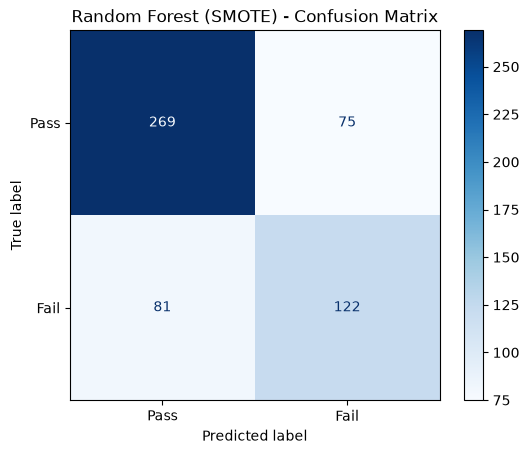

In [23]:
# Confusion Matrix to visualise Random Forest

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf) # Raw counts
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Pass', 'Fail']) # Wrap counts for plotting w labels
disp_rf.plot(cmap="Blues") # Render Matrix
plt.title("Random Forest (SMOTE) - Confusion Matrix") 
plt.show()

The Confusion Matrix for Random Forest shows 122 at-risk students correctly identified (compared to 119 for Logistic Regression with SMOTE), a marginal increase of 3. False alarms sit at 75, close to Logistic Regression's 67. Essentially, this confirms the classification report findings: Random Forest performs almost identically to Logistic Regression. While Random Forests catch slightly more true fails, the cost to this is a few more false alarms so it does not offer a meaningfully different trade-off.

In [24]:
# Feature Importance inspection - what are the drivers

importances_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
})

importances_rf = importances_rf.sort_values('importance', ascending=False) # Biggest driver first
print(importances_rf.head(15))

                       feature  importance
0               Attendance (%)    0.402872
4                vle_avg_score    0.258420
5                vle_red_weeks    0.135633
11     Department_Department C    0.030294
10     Department_Department B    0.027406
16       Year Group_First Year    0.026712
9      Department_Department A    0.024814
19      Year Group_Second Year    0.024709
20       Year Group_Third Year    0.018800
17  Year Group_Foundation Year    0.012998
6               vle_grey_weeks    0.010143
18      Year Group_Fourth Year    0.009404
14    Student Status_PR/Repeat    0.007085
7                 has_grey_vle    0.004214
15       Year Group_Fifth Year    0.003343


The key drivers in Random Forests are intresting and show a completely different imagine of those in Logistic Regression. The top three drivers are Attendance (%) at 0.40 (noting that in Logistic Regression, this was one of the lowest at -0.03), vle_avg_score at 0.26 (versus -0.68) and vle_red_weeks at 0.14 (versus 0.04). Simultaneously, Student Status_PR/Repeat which has high at 1.45 in Logistic Regression is now at a very low 0.007, barely registering as a feature of importance. 

This may be happening as Random Forests capture non-linear interactions that a linear model like Logistic Regression cannot. For example, the model might be learning that a combination of, let's say, below 35% combined with RED VLE weeks implies something specific. This  also supports the multi-signal argument of this project, as the model is picking up different combinations of attendance and engagement as informative.